# Topic Classification Using EmpatheticDialogues

## Objective

The objective of this notebook is to build a single-label topic classification
model for the EmoExpress application using the EmpatheticDialogues dataset.

EmpatheticDialogues contains conversations grounded in emotionally meaningful
situations. However, the dataset does not directly provide the topic labels
required by EmoExpress.

Therefore, this notebook will create a custom topic-classification dataset by
mapping each conversation to one primary EmoExpress topic.

The notebook will:

1. Load the EmpatheticDialogues dataset.
2. Inspect the dataset structure.
3. Group conversation utterances using the conversation identifier.
4. Combine the situation description and dialogue into one text record.
5. Define the EmoExpress topic taxonomy.
6. Generate initial topic labels using weak supervision.
7. Review the topic distribution and ambiguous examples.
8. Prepare training, validation, and test datasets.
9. Train TF-IDF with Logistic Regression.
10. Train TF-IDF with Linear SVM.
11. Fine-tune DistilBERT for multi-class topic classification.
12. Evaluate and compare the models.
13. Save the selected topic classifier for the EmoExpress pipeline.

The predicted topic will later be used to select the appropriate RAG
knowledge-base category and improve supportive-response generation.

Import Libraries

In [3]:
# Standard libraries
import json
import random
import re
import time
from pathlib import Path

# Data processing
import joblib
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

# Hugging Face
from datasets import Dataset, DatasetDict, load_dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

# PyTorch
import torch

Set Random seed

In [5]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print("Random seed:", RANDOM_STATE)

Random seed: 42


Define project paths

In [6]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

MODEL_DIR = PROJECT_ROOT / "models" / "topic_classifier"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "topic_classifier"

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Project root:", PROJECT_ROOT)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Model directory:", MODEL_DIR)
print("Output directory:", OUTPUT_DIR)

Project root: D:\FullStack_Academic\Final Capstone\EmoExpress
Processed data directory: D:\FullStack_Academic\Final Capstone\EmoExpress\data\processed
Model directory: D:\FullStack_Academic\Final Capstone\EmoExpress\models\topic_classifier
Output directory: D:\FullStack_Academic\Final Capstone\EmoExpress\outputs\topic_classifier


Check available device

In [7]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Available device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Available device: cpu


**Define the topic taxonomy**

The topic classifier uses thirteen categories that correspond to the
EmoExpress RAG knowledge-base folders.

The classifier is designed as a single-label classification problem.
Each conversation receives one primary topic even when it contains multiple
issues.

For example:

- Text: "I am worried about losing my job."
- Emotion labels: fear, nervousness, sadness
- Primary topic: career_and_work

In [8]:
TOPIC_LABELS = [
    "career_and_work",
    "education",
    "relationships",
    "family",
    "stress_and_anxiety",
    "grief_and_loss",
    "loneliness",
    "self_confidence",
    "financial_concerns",
    "health_and_wellness",
    "personal_growth",
    "daily_life",
    "general_support",
]

NUM_TOPICS = len(TOPIC_LABELS)

print("Number of topics:", NUM_TOPICS)

for index, topic in enumerate(TOPIC_LABELS):
    print(f"{index}: {topic}")

Number of topics: 13
0: career_and_work
1: education
2: relationships
3: family
4: stress_and_anxiety
5: grief_and_loss
6: loneliness
7: self_confidence
8: financial_concerns
9: health_and_wellness
10: personal_growth
11: daily_life
12: general_support


Define topic descriptions

In [9]:
TOPIC_DEFINITIONS = {
    "career_and_work": (
        "Jobs, workplace issues, coworkers, managers, interviews, "
        "unemployment, promotions, professional goals, or career decisions."
    ),

    "education": (
        "School, college, university, studying, teachers, assignments, "
        "exams, grades, academic performance, or educational decisions."
    ),

    "relationships": (
        "Romantic relationships, dating, marriage, breakups, friendship "
        "conflicts, or interpersonal relationship issues."
    ),

    "family": (
        "Parents, children, siblings, relatives, caregiving, family "
        "responsibilities, or family conflict."
    ),

    "stress_and_anxiety": (
        "Stress, anxiety, worry, nervousness, panic, pressure, fear about "
        "future events, or feeling overwhelmed."
    ),

    "grief_and_loss": (
        "Death, bereavement, mourning, losing a person or pet, separation, "
        "or coping with a major personal loss."
    ),

    "loneliness": (
        "Feeling alone, socially isolated, excluded, disconnected, "
        "ignored, or lacking companionship."
    ),

    "self_confidence": (
        "Self-esteem, insecurity, shame, embarrassment, body image, "
        "personal inadequacy, confidence, or fear of failure."
    ),

    "financial_concerns": (
        "Money, debt, rent, bills, income, affordability, financial "
        "instability, loans, or budgeting."
    ),

    "health_and_wellness": (
        "Physical health, illness, doctors, medical treatment, sleep, "
        "exercise, nutrition, pain, or general wellness."
    ),

    "personal_growth": (
        "Life goals, habits, motivation, identity, self-improvement, "
        "personal development, or making positive changes."
    ),

    "daily_life": (
        "Shopping, food, travel, weather, transportation, entertainment, "
        "appointments, routines, or ordinary daily activities."
    ),

    "general_support": (
        "Emotional support or general conversation that does not clearly "
        "belong to another topic."
    ),
}

for topic, definition in TOPIC_DEFINITIONS.items():
    print(f"\n{topic}")
    print(definition)


career_and_work
Jobs, workplace issues, coworkers, managers, interviews, unemployment, promotions, professional goals, or career decisions.

education
School, college, university, studying, teachers, assignments, exams, grades, academic performance, or educational decisions.

relationships
Romantic relationships, dating, marriage, breakups, friendship conflicts, or interpersonal relationship issues.

family
Parents, children, siblings, relatives, caregiving, family responsibilities, or family conflict.

stress_and_anxiety
Stress, anxiety, worry, nervousness, panic, pressure, fear about future events, or feeling overwhelmed.

grief_and_loss
Death, bereavement, mourning, losing a person or pet, separation, or coping with a major personal loss.

loneliness
Feeling alone, socially isolated, excluded, disconnected, ignored, or lacking companionship.

self_confidence
Self-esteem, insecurity, shame, embarrassment, body image, personal inadequacy, confidence, or fear of failure.

financial_co

**Load EmpatheticDialogues**

In [16]:
empathetic_dataset = load_dataset(
    "Ahren09/empathetic_dialogues"
)

print(empathetic_dataset)

DatasetDict({
    train: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 84169
    })
    validation: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 6340
    })
    test: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 5714
    })
})


Inspect the dataset

In [19]:
print("Available splits:", list(empathetic_dataset.keys()))

for split_name in empathetic_dataset.keys():
    print(f"\nSplit: {split_name}")

    print("Columns:", empathetic_dataset[split_name].column_names)

    print("First example:", empathetic_dataset[split_name][0])

Available splits: ['train', 'validation', 'test']

Split: train
Columns: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags']
First example: {'conv_id': 'hit:0_conv:1', 'utterance_idx': '1', 'context': 'sentimental', 'prompt': 'I remember going to the fireworks with my best friend. There was a lot of people_comma_ but it only felt like us in the world.', 'speaker_idx': '1', 'utterance': 'I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people_comma_ we felt like the only people in the world.', 'selfeval': '5|5|5_2|2|5', 'tags': ''}

Split: validation
Columns: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags']
First example: {'conv_id': 'hit:3_conv:6', 'utterance_idx': '1', 'context': 'terrified', 'prompt': 'Today_comma_as i was leaving for work in the morning_comma_i had a tire burst in the middle of a

Convert every split to pandas

In [ ]:
empathetic_raw_dataframes = []

for split_name in empathetic_dataset.keys():
    split_dataframe = (empathetic_dataset[split_name].to_pandas())

    split_dataframe["original_split"] = split_name

    empathetic_raw_dataframes.append(split_dataframe)

empathetic_raw_df = pd.concat(empathetic_raw_dataframes,ignore_index=True)

print("Raw dataset shape:",empathetic_raw_df.shape)

print("Columns:",empathetic_raw_df.columns.tolist())

empathetic_raw_df.head()

Raw dataset shape: (96223, 9)
Columns: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags', 'original_split']


,conv_id,utterance_idx,context,prompt,speaker_idx,utterance,selfeval,tags,original_split
0,hit:0_conv:1,1,sentimental,I remember going to the fireworks with my best...,1,I remember going to see the fireworks with my ...,5|5|5_2|2|5,,train
1,hit:0_conv:1,2,sentimental,I remember going to the fireworks with my best...,0,Was this a friend you were in love with_comma_...,5|5|5_2|2|5,,train
2,hit:0_conv:1,3,sentimental,I remember going to the fireworks with my best...,1,This was a best friend. I miss her.,5|5|5_2|2|5,,train
3,hit:0_conv:1,4,sentimental,I remember going to the fireworks with my best...,0,Where has she gone?,5|5|5_2|2|5,,train
4,hit:0_conv:1,5,sentimental,I remember going to the fireworks with my best...,1,We no longer talk.,5|5|5_2|2|5,,train


Automatically identify important columns

In [21]:
def find_available_column(dataframe: pd.DataFrame,possible_names: list[str]) -> str | None:
    """
    Return the first available column from a list
    of possible column names.
    """
    for column_name in possible_names:
        if column_name in dataframe.columns:
            return column_name

    return None

In [22]:
conversation_id_column = (find_available_column( empathetic_raw_df, [ "conv_id", "conversation_id", "dialogue_id" ]))

utterance_column = (find_available_column(empathetic_raw_df,["utterance","text", "response"])) 

situation_column = (find_available_column(empathetic_raw_df,["prompt","situation","context_prompt",]))

emotion_column = (find_available_column(empathetic_raw_df,["context","emotion", "emotion_context",]))

print("Conversation ID column:",conversation_id_column)  

print( "Utterance column:",utterance_column)

print("Situation column:",situation_column)

print("Emotion column:",emotion_column)

Conversation ID column: conv_id
Utterance column: utterance
Situation column: prompt
Emotion column: context


Validate the required columns:

In [23]:
if conversation_id_column is None:
    raise ValueError("A conversation ID column was not found.")

if utterance_column is None:
    raise ValueError("An utterance column was not found.")

Sort utterances before grouping. 
This step is important so that the conversation remains in the correct order.

In [24]:
utterance_index_column = (find_available_column(empathetic_raw_df,["utterance_idx","utterance_index","turn_id"]))

if utterance_index_column is not None:
    empathetic_raw_df = (empathetic_raw_df.sort_values(by=[conversation_id_column,utterance_index_column]))

    print("Rows sorted by conversation and utterance order.")
else:
    print("No utterance-order column was found.")

Rows sorted by conversation and utterance order.


Group utterances into conversations

In [25]:
def get_first_non_empty_value(values) -> str:
    """
    Return the first valid non-empty value.
    """
    for value in values:
        if pd.notna(value):
            cleaned_value = str(value).strip()

            if cleaned_value:
                return cleaned_value

    return ""

In [ ]:
# Build the aggregation rules
aggregation_rules = {utterance_column: (lambda values: " ".join(str(value).strip() 
                                        for value in values if pd.notna(value) and str(value).strip())),"original_split": "first"}

if situation_column is not None:
    aggregation_rules[situation_column] = get_first_non_empty_value

if emotion_column is not None:
    aggregation_rules[emotion_column] = get_first_non_empty_value

In [27]:
# Group the rows
empathetic_grouped_df = (empathetic_raw_df.groupby(conversation_id_column, as_index=False).agg(aggregation_rules))

In [28]:
# Rename the combined utterance columns
empathetic_grouped_df = (empathetic_grouped_df.rename(columns={utterance_column: ("dialogue_text")}))

**Build the final topic classification text**

In [29]:
def build_empathetic_text(row: pd.Series) -> str:
    """
    Combine the situation description and dialogue
    into one topic-classification input.
    """
    text_parts = []

    if situation_column is not None:
        situation = str(row.get(situation_column,"")).strip()

        if (situation and situation.lower() != "nan"):
            text_parts.append(f"Situation: {situation}")

    dialogue = str(row.get("dialogue_text","" )).strip()

    if (dialogue and dialogue.lower() != "nan" ):
        
        text_parts.append( f"Conversation: {dialogue}" )

    return " ".join(text_parts).strip()

In [30]:
# apply it
empathetic_grouped_df["text"] = (empathetic_grouped_df.apply(build_empathetic_text,axis=1))

empathetic_grouped_df["source"] = ("empathetic_dialogues")

empathetic_grouped_df["conversation_id"] = (empathetic_grouped_df[conversation_id_column].apply(lambda value: (f"empathetic_{value}")))

In [31]:
# Create the final dataframe
empathetic_df = (empathetic_grouped_df[[ "conversation_id","text","source","original_split"]].copy())

empathetic_df = empathetic_df[empathetic_df["text"].astype(str) .str.strip() .ne("") ].reset_index(drop=True)

print("Prepared dataset shape:", empathetic_df.shape)

empathetic_df.head()

Prepared dataset shape: (24850, 4)


,conversation_id,text,source,original_split
0,empathetic_hit:0_conv:0,Situation: I felt guilty when I was driving ho...,empathetic_dialogues,test
1,empathetic_hit:0_conv:1,Situation: I remember going to the fireworks w...,empathetic_dialogues,train
2,empathetic_hit:10000_conv:20000,Situation: My girlfriend got me a toad today! ...,empathetic_dialogues,train
3,empathetic_hit:10000_conv:20001,Situation: I really like the new paint job on ...,empathetic_dialogues,train
4,empathetic_hit:10001_conv:20002,Situation: I went to the skating rink all by m...,empathetic_dialogues,train


Inspect complete conversations

In [32]:
for index in range(min(5,len(empathetic_df))):
    print(f"\nConversation {index + 1}")

    print("-" * 100)

    print(empathetic_df.iloc[index]["text"])


Conversation 1
----------------------------------------------------------------------------------------------------
Situation: I felt guilty when I was driving home one night and a person tried to fly into my lane_comma_ and didn't see me. I honked and they swerved back into their lane_comma_ slammed on their brakes_comma_ and hit the water cones. Conversation: Yeah about 10 years ago I had a horrifying experience. It was 100% their fault but they hit the water barrels and survived. They had no injuries but they almost ran me off the road. No I wasn't hit. It turned out they were drunk. I felt guilty but realized it was his fault. I don't know I was new to driving and hadn't experienced anything like that. I felt like my horn made him swerve into the water barrels.

Conversation 2
----------------------------------------------------------------------------------------------------
Situation: I remember going to the fireworks with my best friend. There was a lot of people_comma_ but it 

In [ ]:
# create a copy of empathetic_df
topic_raw_df = empathetic_df.copy()

print("Topic dataset shape:",topic_raw_df.shape)

topic_raw_df.head()

Topic dataset shape: (24850, 4)


,conversation_id,text,source,original_split
0,empathetic_hit:0_conv:0,Situation: I felt guilty when I was driving ho...,empathetic_dialogues,test
1,empathetic_hit:0_conv:1,Situation: I remember going to the fireworks w...,empathetic_dialogues,train
2,empathetic_hit:10000_conv:20000,Situation: My girlfriend got me a toad today! ...,empathetic_dialogues,train
3,empathetic_hit:10000_conv:20001,Situation: I really like the new paint job on ...,empathetic_dialogues,train
4,empathetic_hit:10001_conv:20002,Situation: I went to the skating rink all by m...,empathetic_dialogues,train


**Apply text cleaning**

In [34]:
def clean_topic_text(text: str) -> str:
    """
    Perform light text cleaning for topic classification.
    """
    if not isinstance(text, str):
        return ""

    text = re.sub(r"https?://\S+|www\.\S+"," ",text)

    text = re.sub( r"\s+"," ",text,)

    return text.strip()

In [35]:
topic_raw_df["clean_text"] = (topic_raw_df["text"].apply( clean_topic_text))

topic_raw_df = topic_raw_df[topic_raw_df["clean_text"].str.len()>= 15].copy()

topic_raw_df = (topic_raw_df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True))

print("Dataset shape after cleaning:",topic_raw_df.shape)

Dataset shape after cleaning: (24850, 5)


In [38]:
topic_raw_df.head(5)

,conversation_id,text,source,original_split,clean_text
0,empathetic_hit:0_conv:0,Situation: I felt guilty when I was driving ho...,empathetic_dialogues,test,Situation: I felt guilty when I was driving ho...
1,empathetic_hit:0_conv:1,Situation: I remember going to the fireworks w...,empathetic_dialogues,train,Situation: I remember going to the fireworks w...
2,empathetic_hit:10000_conv:20000,Situation: My girlfriend got me a toad today! ...,empathetic_dialogues,train,Situation: My girlfriend got me a toad today! ...
3,empathetic_hit:10000_conv:20001,Situation: I really like the new paint job on ...,empathetic_dialogues,train,Situation: I really like the new paint job on ...
4,empathetic_hit:10001_conv:20002,Situation: I went to the skating rink all by m...,empathetic_dialogues,train,Situation: I went to the skating rink all by m...


Retain the original EmpatheticDialogues emotion

In [36]:
# Add it to the final dataframe when available
selected_columns = ["conversation_id","text","source","original_split"]

if emotion_column is not None:
    selected_columns.append(emotion_column)

empathetic_df = (empathetic_grouped_df[selected_columns].copy())

In [37]:
# rename it
if (emotion_column is not None and emotion_column in empathetic_df.columns):
    empathetic_df = (empathetic_df.rename(columns={emotion_column: ("original_emotion")}))

**Examine conversation length**

Before creating topic labels, the length of each conversation is examined.

Conversation length is useful for:

- Detecting empty or unusually short examples
- Identifying extremely long conversations
- Selecting an appropriate maximum token length for DistilBERT

In [39]:
topic_raw_df["word_count"] = (topic_raw_df["clean_text"].str.split().str.len())

topic_raw_df["word_count"].describe()

count    24850.000000
mean        74.261006
std         31.321508
min         10.000000
25%         53.000000
50%         68.000000
75%         88.000000
max        396.000000
Name: word_count, dtype: float64

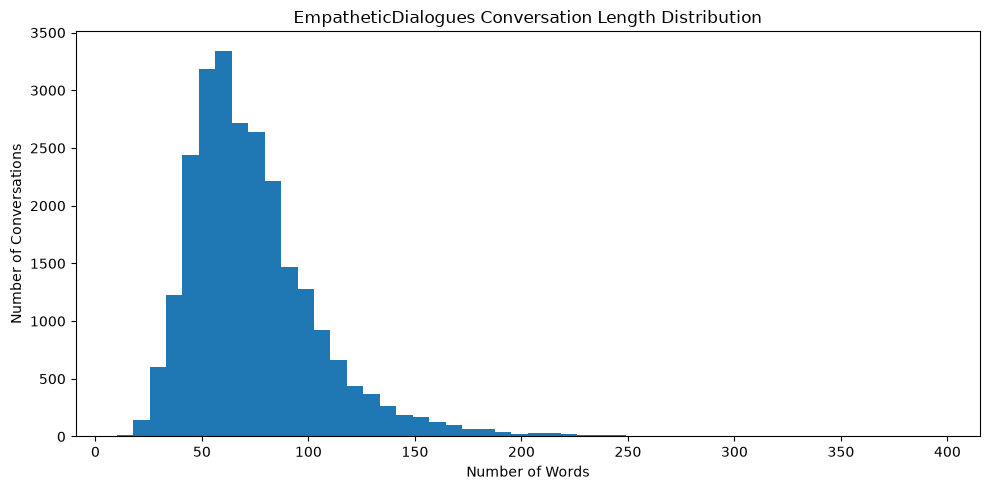

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(topic_raw_df["word_count"],bins=50)

plt.title("EmpatheticDialogues Conversation Length Distribution")

plt.xlabel("Number of Words")
plt.ylabel("Number of Conversations")

plt.tight_layout()
plt.show()

In [41]:
# Inspect longest conversation
topic_raw_df.sort_values(by="word_count",ascending=False)[["conversation_id","word_count","clean_text"]].head()

,conversation_id,word_count,clean_text
12250,empathetic_hit:4330_conv:8660,396,Situation: Life can be really not a happy plac...
15104,empathetic_hit:5615_conv:11230,378,Situation: I got some fast food today and it w...
12345,empathetic_hit:4373_conv:8747,375,Situation: You know that feeling when loneline...
13568,empathetic_hit:4924_conv:9848,331,Situation: I had spent ages organising a lovel...
5405,empathetic_hit:124_conv:249,312,Situation: I had a girl that I was seeing one ...


**Define the topic keywords**

EmpatheticDialogues provides emotion-related labels but does not provide the custom topic labels required by EmoExpress.

Therefore, initial topic labels are generated using weak supervision.

Keyword rules are used to identify the primary topic discussed in each conversation. These labels are provisional and should be reviewed before
being treated as reliable training labels.

In [42]:
TOPIC_KEYWORDS = {
    "career_and_work": [
        "job",
        "jobs",
        "work",
        "working",
        "workplace",
        "office",
        "boss",
        "manager",
        "coworker",
        "colleague",
        "career",
        "interview",
        "promotion",
        "promoted",
        "fired",
        "laid off",
        "unemployed",
        "unemployment",
        "salary",
        "resume",
        "profession",
        "business",
        "company",
    ],

    "education": [
        "school",
        "college",
        "university",
        "class",
        "teacher",
        "professor",
        "student",
        "exam",
        "test",
        "quiz",
        "homework",
        "assignment",
        "degree",
        "study",
        "studying",
        "grade",
        "graduation",
        "campus",
        "course",
    ],

    "relationships": [
        "boyfriend",
        "girlfriend",
        "partner",
        "husband",
        "wife",
        "dating",
        "date",
        "relationship",
        "breakup",
        "broke up",
        "marriage",
        "married",
        "friend",
        "friends",
        "friendship",
        "best friend",
        "romantic",
        "divorce",
    ],

    "family": [
        "family",
        "mother",
        "father",
        "mom",
        "dad",
        "parent",
        "parents",
        "brother",
        "sister",
        "sibling",
        "daughter",
        "son",
        "child",
        "children",
        "grandmother",
        "grandfather",
        "grandparent",
        "relative",
        "uncle",
        "aunt",
        "cousin",
    ],

    "stress_and_anxiety": [
        "stress",
        "stressed",
        "stressful",
        "anxiety",
        "anxious",
        "nervous",
        "worried",
        "worry",
        "panic",
        "panicking",
        "overwhelmed",
        "pressure",
        "afraid",
        "fearful",
        "tense",
        "scared",
        "concerned",
    ],

    "grief_and_loss": [
        "died",
        "death",
        "passed away",
        "funeral",
        "grief",
        "grieving",
        "mourning",
        "loss",
        "lost someone",
        "lost my",
        "deceased",
        "dead",
        "memorial",
        "burial",
        "passed",
    ],

    "loneliness": [
        "lonely",
        "loneliness",
        "alone",
        "isolated",
        "isolation",
        "no friends",
        "left out",
        "excluded",
        "nobody",
        "no one cares",
        "by myself",
        "abandoned",
        "ignored",
    ],

    "self_confidence": [
        "confidence",
        "confident",
        "insecure",
        "insecurity",
        "worthless",
        "failure",
        "failed",
        "not good enough",
        "self-esteem",
        "self esteem",
        "embarrassed",
        "embarrassing",
        "ashamed",
        "ugly",
        "unattractive",
        "proud of myself",
        "doubt myself",
    ],

    "financial_concerns": [
        "money",
        "financial",
        "finances",
        "rent",
        "debt",
        "loan",
        "bill",
        "bills",
        "afford",
        "income",
        "bank",
        "budget",
        "expensive",
        "poor",
        "payment",
        "mortgage",
        "credit card",
        "paycheck",
        "cost",
    ],

    "health_and_wellness": [
        "health",
        "healthy",
        "doctor",
        "hospital",
        "sick",
        "ill",
        "illness",
        "pain",
        "medicine",
        "medical",
        "sleep",
        "exercise",
        "diet",
        "nutrition",
        "disease",
        "injury",
        "injured",
        "surgery",
        "treatment",
        "weight",
    ],

    "personal_growth": [
        "goal",
        "goals",
        "improve myself",
        "self-improvement",
        "self improvement",
        "habit",
        "motivation",
        "motivated",
        "future",
        "change my life",
        "personal growth",
        "become better",
        "learn from",
        "new beginning",
        "achievement",
        "accomplishment",
        "progress",
    ],

    "daily_life": [
        "shopping",
        "restaurant",
        "food",
        "cooking",
        "travel",
        "trip",
        "vacation",
        "weather",
        "weekend",
        "appointment",
        "bus",
        "train",
        "car",
        "movie",
        "music",
        "party",
        "game",
        "store",
        "concert",
        "birthday",
        "holiday",
    ],
}

Create the topic-scoring function

In [43]:
def calculate_topic_scores(text: str) -> dict[str, int]:
    """
    Count keyword matches for every topic.

    Parameters
    ----------
    text:
        Conversation text.

    Returns
    -------
    dict
        Mapping of topic names to keyword-match scores.
    """
    normalized_text = str(text).lower()

    scores = {}

    for topic, keywords in TOPIC_KEYWORDS.items():
        topic_score = 0

        for keyword in keywords:
            pattern = (r"\b"+ re.escape(keyword.lower()) + r"\b")

            matches = re.findall(pattern,normalized_text)

            topic_score += len(matches)

        scores[topic] = topic_score

    return scores

Create the topic-assignment function

This function returns:

- Best topic
- Highest topic score
- Second-highest score
- Difference between the top two scores
- Whether the example is ambiguous

In [44]:
def assign_keyword_topic(text: str) -> dict:
    """
    Assign one primary topic using keyword scores.

    If no topic keywords are found, the example is assigned
    to general_support.
    """
    scores = calculate_topic_scores(text)

    sorted_scores = sorted(scores.items(),key=lambda item: item[1],reverse=True)

    best_topic, best_score = sorted_scores[0]

    second_best_topic, second_best_score = (sorted_scores[1] if len(sorted_scores) > 1 else ("general_support", 0))

    if best_score == 0:
        return {
            "topic": "general_support",
            "keyword_score": 0,
            "second_topic": None,
            "second_score": 0,
            "score_difference": 0,
            "is_ambiguous": True,
        }

    score_difference = (best_score - second_best_score)

    return {"topic": best_topic,
        "keyword_score": best_score,
        "second_topic": second_best_topic,
        "second_score": second_best_score,
        "score_difference": score_difference,
        "is_ambiguous": (score_difference == 0)}

In [ ]:
# test the function
sample_text = ("I am worried that I may lose my job and I cannot afford my bills.")

assign_keyword_topic(sample_text)

{'topic': 'financial_concerns',
 'keyword_score': 2,
 'second_topic': 'career_and_work',
 'second_score': 1,
 'score_difference': 1,
 'is_ambiguous': False}

Apply the topic-labeling function

In [46]:
keyword_label_results = (topic_raw_df["clean_text"].apply(assign_keyword_topic))

In [48]:
topic_raw_df["topic"] = (keyword_label_results.apply(lambda result: result["topic"]))

topic_raw_df["keyword_score"] = (keyword_label_results.apply(lambda result: result["keyword_score"]))

topic_raw_df["second_topic"] = (keyword_label_results.apply(lambda result: result["second_topic"]))
    
topic_raw_df["second_score"] = (keyword_label_results.apply(lambda result: result["second_score"]))

topic_raw_df["score_difference"] = (keyword_label_results.apply(lambda result: result["score_difference"]))
    
topic_raw_df["is_ambiguous"] = (keyword_label_results.apply( lambda result: result["is_ambiguous"]))

topic_raw_df.head(5)

,conversation_id,text,source,original_split,clean_text,word_count,topic,keyword_score,second_topic,second_score,score_difference,is_ambiguous
0,empathetic_hit:0_conv:0,Situation: I felt guilty when I was driving ho...,empathetic_dialogues,test,Situation: I felt guilty when I was driving ho...,123,general_support,0,NaN,0,0,True
1,empathetic_hit:0_conv:1,Situation: I remember going to the fireworks w...,empathetic_dialogues,train,Situation: I remember going to the fireworks w...,105,relationships,9,loneliness,1,8,False
2,empathetic_hit:10000_conv:20000,Situation: My girlfriend got me a toad today! ...,empathetic_dialogues,train,Situation: My girlfriend got me a toad today! ...,54,relationships,2,career_and_work,0,2,False
3,empathetic_hit:10000_conv:20001,Situation: I really like the new paint job on ...,empathetic_dialogues,train,Situation: I really like the new paint job on ...,52,career_and_work,2,education,0,2,False
4,empathetic_hit:10001_conv:20002,Situation: I went to the skating rink all by m...,empathetic_dialogues,train,Situation: I went to the skating rink all by m...,83,relationships,3,loneliness,3,0,True


Inspect the initial topic distribution

In [49]:
topic_distribution_df = (topic_raw_df["topic"].value_counts().rename_axis("topic").reset_index(name="count"))

topic_distribution_df["percentage"] = (topic_distribution_df["count"]/ topic_distribution_df["count"].sum()* 100)

topic_distribution_df

,topic,count,percentage
0,general_support,4416,17.770624
1,relationships,3693,14.861167
2,career_and_work,3564,14.342052
3,family,3488,14.036217
4,daily_life,3269,13.154930
5,education,2077,8.358149
6,stress_and_anxiety,1240,4.989940
7,financial_concerns,888,3.573441
8,health_and_wellness,791,3.183099
9,grief_and_loss,629,2.531187


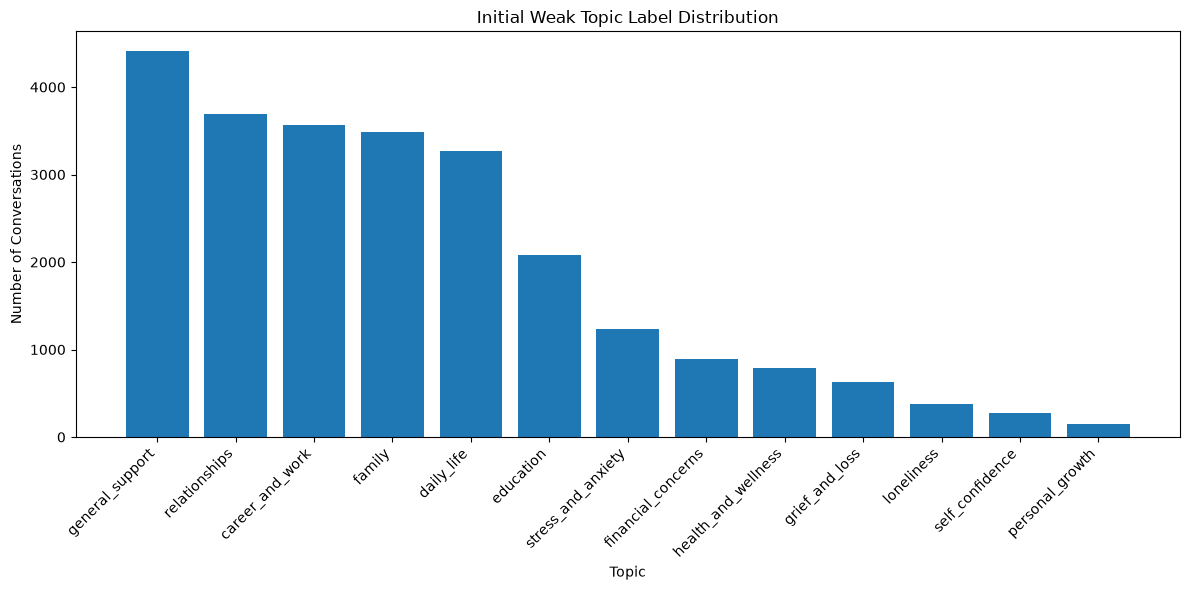

In [50]:
plt.figure(figsize=(12, 6))

plt.bar(topic_distribution_df["topic"],topic_distribution_df["count"])

plt.title("Initial Weak Topic Label Distribution")

plt.xlabel("Topic")
plt.ylabel("Number of Conversations")

plt.xticks(rotation=45,ha="right")

plt.tight_layout()
plt.show()

Analyze keyword confidence

In [51]:
print("Total conversations:",len(topic_raw_df))

print("Conversations with keyword matches:",(topic_raw_df["keyword_score"] > 0 ).sum())

print("Conversations without keyword matches:",(topic_raw_df["keyword_score"] == 0).sum())

print("Ambiguous conversations:",topic_raw_df["is_ambiguous"].sum())

Total conversations: 24850
Conversations with keyword matches: 20434
Conversations without keyword matches: 4416
Ambiguous conversations: 7791


In [52]:
matched_percentage = ((topic_raw_df["keyword_score"] > 0).mean()* 100)

ambiguous_percentage = (topic_raw_df["is_ambiguous"].mean()* 100)

print(f"Keyword-match percentage: "f"{matched_percentage:.2f}%")

print(f"Ambiguous-label percentage: "f"{ambiguous_percentage:.2f}%")

Keyword-match percentage: 82.23%
Ambiguous-label percentage: 31.35%


Display examples by topic

In [53]:
def display_topic_examples(dataframe: pd.DataFrame,topic: str,number_of_examples: int = 5) -> None:
    """
    Display random conversations assigned to a topic.
    """
    topic_dataframe = dataframe[dataframe["topic"] == topic]

    if topic_dataframe.empty:
        print(f"No examples found for: {topic}")
        return

    sample_size = min(number_of_examples,len(topic_dataframe))

    sample_dataframe = (topic_dataframe.sample(n=sample_size,random_state=RANDOM_STATE))

    for example_number, (_, row) in enumerate(sample_dataframe.iterrows(),start=1):
        print(f"\nExample {example_number}")

        print(f"Topic: {row['topic']}")
            

        print(f"Keyword score: {row['keyword_score']}")
            

        print(f"Second topic: {row['second_topic']}")
            

        print(f"Original emotion: {row.get('original_emotion', 'N/A')}")
           

        print(row["clean_text"])

        print("-" * 100)

In [55]:
display_topic_examples(dataframe=topic_raw_df, topic="career_and_work", number_of_examples=3)


Example 1
Topic: career_and_work
Keyword score: 3
Second topic: education
Original emotion: N/A
Situation: I was proud when my brother graduated college. He had to work hard but he got through it. Conversation: My little brother graduated not too long ago. He had to work hard but made it through it. He did! He actually just started a new job that he loves and is related to his degree.
----------------------------------------------------------------------------------------------------

Example 2
Topic: career_and_work
Keyword score: 2
Second topic: relationships
Original emotion: N/A
Situation: I'm unemployed and struggling right now. I feel really bad when people talk to me about their new houses and clothes and stuff_comma_ even though they're not trying to be mean Conversation: I'm unemployed and struggling right now. I feel really bad when people talk to me about their new stuff_comma_ even though they're not trying to be mean yeah! I just want to be able to support myself and not 

In [57]:
display_topic_examples(dataframe=topic_raw_df, topic="relationships", number_of_examples=3)


Example 1
Topic: relationships
Keyword score: 4
Second topic: education
Original emotion: N/A
Situation: My best friend is returning to college after an academic suspension. I hope that this semester will be different since I'm taking the same classes as her. Conversation: My best friend is finally able to come back to school after an academic suspension. That's good! Was there a reason for the suspension? She had failed too many classes. We're in the same classes this semester_comma_ so that should help keep her on track. It'll be good for her to have your support_comma_ so hopefully she'll do better this semester. Thanks! I hope so as well.
----------------------------------------------------------------------------------------------------

Example 2
Topic: relationships
Keyword score: 2
Second topic: daily_life
Original emotion: N/A
Situation: I came home from grocery shopping to find that my husband had cleaned the entire house up and started dinner. I was amazed. Conversation: I 

In [58]:
display_topic_examples(dataframe=topic_raw_df, topic="stress_and_anxiety", number_of_examples=3)


Example 1
Topic: stress_and_anxiety
Keyword score: 2
Second topic: career_and_work
Original emotion: N/A
Situation: Our dog started barking a lot in the middle of the night. I was looking out the windows trying to see if someone was out there. It was too dark to see anything. Conversation: I'm so tired. I was awake for hours last night. Oh_comma_ sorry to hear that. I was under a lot of stress. What happened to you? Our dog was baking and I couldn't see what he was all upset about. He never bark like that. Oh no_comma_ sorry hope it wasn't a snake. My hound dog is alwayd barking. What was stressful for you? Yah_comma_ lost my job and trying to find a new one.
----------------------------------------------------------------------------------------------------

Example 2
Topic: stress_and_anxiety
Keyword score: 3
Second topic: relationships
Original emotion: N/A
Situation: I am scared of how I will die. Conversation: I am scared of how I will die. I worry about that too occasionally_com

Inspect ambiguous labels

In [59]:
ambiguous_df = topic_raw_df[topic_raw_df["is_ambiguous"]].copy()
    
print( "Ambiguous examples:",len(ambiguous_df))

Ambiguous examples: 7791


In [60]:
ambiguous_columns = ["clean_text","topic","keyword_score","second_topic","second_score","original_emotion"]

available_ambiguous_columns = [ column for column in ambiguous_columns if column in ambiguous_df.columns]

ambiguous_df[available_ambiguous_columns].sample(n=min(10,len(ambiguous_df)),random_state=RANDOM_STATE)

,clean_text,topic,keyword_score,second_topic,second_score
4737,Situation: I really miss my man_comma_ he went...,career_and_work,2,daily_life,2
18569,Situation: The sun is shining and I ahve no pl...,general_support,0,NaN,0
17013,Situation: I cant wait for the football season...,general_support,0,NaN,0
3465,Situation: The first time my brother was comin...,education,2,family,2
323,Situation: This weekend the family is going to...,family,2,financial_concerns,2
17158,Situation: i dont like hospitals Conversation:...,stress_and_anxiety,1,health_and_wellness,1
1647,Situation: One time a person offered to drive ...,general_support,0,NaN,0
19463,Situation: I really do not like the new text a...,general_support,0,NaN,0
24783,Situation: I'm ready to cook tonight! Conversa...,general_support,0,NaN,0
20559,Situation: Recently my son got very good news ...,family,2,health_and_wellness,2


**Export a manual-review sample**

Because the initial topic labels are produced using keyword rules, a stratified sample is exported for manual inspection.

The reviewer can complete the following columns:

- `reviewed_topic`
- `is_correct`
- `review_notes`

This review helps estimate the quality of the weak labels.

In [61]:
MANUAL_REVIEW_SAMPLES_PER_TOPIC = 20

In [62]:
manual_review_dataframes = []

for topic, topic_dataframe in (topic_raw_df.groupby("topic")):
    sample_size = min(MANUAL_REVIEW_SAMPLES_PER_TOPIC,len(topic_dataframe))

    sampled_topic_dataframe = (topic_dataframe.sample(n=sample_size,random_state=RANDOM_STATE))

    manual_review_dataframes.append(sampled_topic_dataframe)

manual_review_df = pd.concat(manual_review_dataframes,ignore_index=True)

manual_review_df["reviewed_topic"] = ""

manual_review_df["is_correct"] = ""

manual_review_df["review_notes"] = ""

In [63]:
MANUAL_REVIEW_PATH = (OUTPUT_DIR/ "topic_label_manual_review.csv")

manual_review_df.to_csv(MANUAL_REVIEW_PATH,index=False)

print("Manual-review file saved to:",MANUAL_REVIEW_PATH)

print("Number of review examples:",len(manual_review_df))

Manual-review file saved to: D:\FullStack_Academic\Final Capstone\EmoExpress\outputs\topic_classifier\topic_label_manual_review.csv
Number of review examples: 260


Filter the labeled dataset

In [64]:
matched_non_ambiguous_df = topic_raw_df[(topic_raw_df["keyword_score"] >= 1) & (~topic_raw_df["is_ambiguous"])].copy()

print("Matched non-ambiguous examples:",matched_non_ambiguous_df.shape)

Matched non-ambiguous examples: (17059, 12)


In [65]:
# Select a controlled sample of unmatched examples for general_support:
general_support_df = topic_raw_df[topic_raw_df["keyword_score"] == 0].copy()

general_support_df["topic"] = ("general_support")

MAX_GENERAL_SUPPORT_SAMPLES = 2_500

if (len(general_support_df) > MAX_GENERAL_SUPPORT_SAMPLES):
    general_support_df = (general_support_df.sample(n=MAX_GENERAL_SUPPORT_SAMPLES,random_state=RANDOM_STATE))

print("General-support examples:",general_support_df.shape)

General-support examples: (2500, 12)


In [66]:
# combine the selected data
labeled_df = pd.concat([matched_non_ambiguous_df,general_support_df],ignore_index=True)

labeled_df = (labeled_df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True))

print("Labeled dataset shape:",labeled_df.shape)

Labeled dataset shape: (19559, 12)


Check class sizes

In [67]:
class_counts = (labeled_df["topic"].value_counts().reindex(TOPIC_LABELS,fill_value=0))

class_counts

topic
career_and_work        2736
education              1587
relationships          2866
family                 2824
stress_and_anxiety      993
grief_and_loss          570
loneliness              332
self_confidence         233
financial_concerns      796
health_and_wellness     720
personal_growth         133
daily_life             3269
general_support        2500
Name: count, dtype: int64

In [68]:
MINIMUM_CLASS_SIZE = 20

small_classes = class_counts[class_counts < MINIMUM_CLASS_SIZE]

if small_classes.empty:
    print("All topic classes contain at least {MINIMUM_CLASS_SIZE} examples.")
else:
    print("The following topic classes contain too few examples:")
    print(small_classes)

All topic classes contain at least {MINIMUM_CLASS_SIZE} examples.


In [69]:
valid_topics = class_counts[class_counts >= MINIMUM_CLASS_SIZE].index.tolist()

labeled_df = labeled_df[labeled_df["topic"].isin(valid_topics)].reset_index(drop=True)

print("Topics retained:",valid_topics)

print("Dataset shape:",labeled_df.shape)

Topics retained: ['career_and_work', 'education', 'relationships', 'family', 'stress_and_anxiety', 'grief_and_loss', 'loneliness', 'self_confidence', 'financial_concerns', 'health_and_wellness', 'personal_growth', 'daily_life', 'general_support']
Dataset shape: (19559, 12)


Cap very large dataset

In [70]:
MAX_SAMPLES_PER_TOPIC = 3_000

balanced_dataframes = []

for topic, topic_dataframe in (labeled_df.groupby("topic")):
    if (len(topic_dataframe) > MAX_SAMPLES_PER_TOPIC):
        topic_dataframe = (topic_dataframe.sample(n=MAX_SAMPLES_PER_TOPIC,random_state=RANDOM_STATE))

    balanced_dataframes.append(topic_dataframe)

balanced_df = pd.concat(balanced_dataframes,ignore_index=True)

balanced_df = (balanced_df.sample(frac=1,random_state=RANDOM_STATE).reset_index(drop=True))

print("Balanced dataset shape:",balanced_df.shape)

balanced_df["topic"].value_counts()

Balanced dataset shape: (19290, 12)


topic
daily_life             3000
relationships          2866
family                 2824
career_and_work        2736
general_support        2500
education              1587
stress_and_anxiety      993
financial_concerns      796
health_and_wellness     720
grief_and_loss          570
loneliness              332
self_confidence         233
personal_growth         133
Name: count, dtype: int64

Visualize the final training distribution

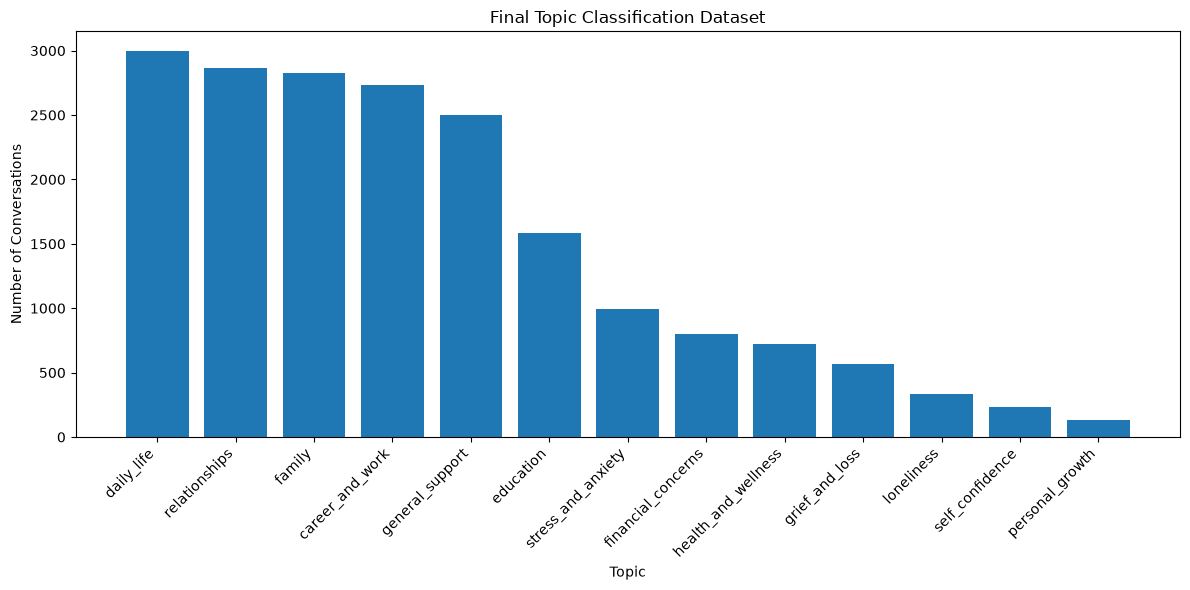

In [71]:
balanced_topic_counts = (balanced_df["topic"].value_counts().sort_values(ascending=False))

plt.figure(figsize=(12, 6))

plt.bar(balanced_topic_counts.index,balanced_topic_counts.values)

plt.title("Final Topic Classification Dataset")

plt.xlabel("Topic")
plt.ylabel("Number of Conversations")

plt.xticks(rotation=45,ha="right")

plt.tight_layout()
plt.show()

Save the labeled dataset

In [72]:
LABELED_DATA_PATH = (PROCESSED_DATA_DIR/ "empathetic_topic_classification_dataset.csv")

balanced_df.to_csv(LABELED_DATA_PATH,index=False)

print("Labeled dataset saved to:",LABELED_DATA_PATH)

Labeled dataset saved to: D:\FullStack_Academic\Final Capstone\EmoExpress\data\processed\empathetic_topic_classification_dataset.csv


In [73]:
# Save a compact version:
COMPACT_DATA_PATH = (PROCESSED_DATA_DIR/ "empathetic_topic_text_labels.csv")

compact_topic_df = balanced_df[["clean_text","topic","original_split","original_emotion"]].copy()

compact_topic_df = (compact_topic_df.rename(columns={"clean_text": "text"}))

compact_topic_df.to_csv(COMPACT_DATA_PATH,index=False)

print("Compact dataset saved to:",COMPACT_DATA_PATH)

KeyError: "['original_emotion'] not in index"

Encode topic labels

In [74]:
label_encoder = LabelEncoder()

balanced_df["label"] = (label_encoder.fit_transform(balanced_df["topic"]))

TOPIC_NAMES = list(label_encoder.classes_)

NUM_LABELS = len(TOPIC_NAMES)

print("Number of labels:",NUM_LABELS)

for label_id, topic_name in enumerate(TOPIC_NAMES):
    print(f"{label_id}: {topic_name}")

Number of labels: 13
0: career_and_work
1: daily_life
2: education
3: family
4: financial_concerns
5: general_support
6: grief_and_loss
7: health_and_wellness
8: loneliness
9: personal_growth
10: relationships
11: self_confidence
12: stress_and_anxiety


Split the dataset

In [75]:
train_df, temporary_df = train_test_split(balanced_df,
                                        test_size=0.30,
                                        random_state=RANDOM_STATE,
                                        stratify=balanced_df["topic"])

validation_df, test_df = train_test_split(temporary_df,
                                        test_size=0.50,
                                        random_state=RANDOM_STATE,
                                        stratify=temporary_df["topic"])

In [76]:
train_df = train_df.reset_index(drop=True)

validation_df = validation_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)

print("Training set:",train_df.shape)

print("Validation set:",validation_df.shape)

print("Test set:",test_df.shape)

Training set: (13503, 13)
Validation set: (2893, 13)
Test set: (2894, 13)


Check split distributions

In [78]:
def display_split_distribution(dataframe: pd.DataFrame,split_name: str) -> None:
    """
    Display topic counts and proportions for a split.
    """
    counts = (dataframe["topic"].value_counts().reindex(TOPIC_NAMES,fill_value=0))

    proportions = (dataframe["topic"].value_counts(normalize=True).reindex(TOPIC_NAMES,fill_value=0))

    output_df = pd.DataFrame({"count": counts,"proportion": proportions})

    print(f"\n{split_name}")
    print("-" * 60)
    print(output_df)

In [79]:
display_split_distribution(train_df,"Training Set")


Training Set
------------------------------------------------------------
                     count  proportion
topic                                 
career_and_work       1915    0.141820
daily_life            2100    0.155521
education             1111    0.082278
family                1977    0.146412
financial_concerns     557    0.041250
general_support       1750    0.129601
grief_and_loss         399    0.029549
health_and_wellness    504    0.037325
loneliness             233    0.017255
personal_growth         93    0.006887
relationships         2006    0.148560
self_confidence        163    0.012071
stress_and_anxiety     695    0.051470


In [80]:

display_split_distribution(validation_df,"Validation Set")


Validation Set
------------------------------------------------------------
                     count  proportion
topic                                 
career_and_work        410    0.141721
daily_life             450    0.155548
education              238    0.082268
family                 423    0.146215
financial_concerns     119    0.041134
general_support        375    0.129623
grief_and_loss          86    0.029727
health_and_wellness    108    0.037331
loneliness              50    0.017283
personal_growth         20    0.006913
relationships          430    0.148635
self_confidence         35    0.012098
stress_and_anxiety     149    0.051504


In [81]:

display_split_distribution(test_df,"Test Set")


Test Set
------------------------------------------------------------
                     count  proportion
topic                                 
career_and_work        411    0.142018
daily_life             450    0.155494
education              238    0.082239
family                 424    0.146510
financial_concerns     120    0.041465
general_support        375    0.129578
grief_and_loss          85    0.029371
health_and_wellness    108    0.037319
loneliness              49    0.016932
personal_growth         20    0.006911
relationships          430    0.148583
self_confidence         35    0.012094
stress_and_anxiety     149    0.051486


In [82]:
# Save the splits
TRAIN_DATA_PATH = (PROCESSED_DATA_DIR/ "topic_train.csv")

VALIDATION_DATA_PATH = (PROCESSED_DATA_DIR/ "topic_validation.csv")

TEST_DATA_PATH = (PROCESSED_DATA_DIR/ "topic_test.csv")

train_df.to_csv(TRAIN_DATA_PATH,index=False)

validation_df.to_csv(VALIDATION_DATA_PATH,index=False)

test_df.to_csv(TEST_DATA_PATH,index=False)

print("Dataset splits saved successfully.")

Dataset splits saved successfully.


**Define the evaluation function**

This is a single-label, multi-class classification problem.

The models are evaluated using:

- Accuracy
- Macro precision
- Macro recall
- Macro F1
- Weighted precision
- Weighted recall
- Weighted F1
- Training time
- Inference time

Macro F1 is the main model-selection metric because it gives equal importance to every topic class.

In [83]:
def evaluate_topic_model(y_true,
                            y_pred,
                            model_name: str,
                            training_time_seconds: float,
                            inference_time_seconds: float) -> dict:
    """
    Evaluate a single-label topic classifier.
    """
    accuracy = accuracy_score(y_true,y_pred)

    (macro_precision,macro_recall,macro_f1, _,) = precision_recall_fscore_support(y_true, y_pred,average="macro",zero_division=0)
                                               
    (weighted_precision,weighted_recall,weighted_f1,_,) = precision_recall_fscore_support(y_true,y_pred,average="weighted",zero_division=0)

    print(f"\n{model_name}")
    print("=" * 80)

    print(classification_report(y_true,y_pred,labels=TOPIC_NAMES,zero_division=0))

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "training_time_seconds": (training_time_seconds),
        "inference_time_seconds": (inference_time_seconds)}

In [84]:
topic_model_results = []

In [ ]:

Cell 37 — Train TF-IDF with Logistic Regression
## Model 1: TF-IDF with Logistic Regression

This model provides a traditional machine-learning baseline.

TF-IDF represents each conversation using unigram and bigram features.
Logistic Regression then predicts one primary topic.
logistic_regression_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20_000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                lowercase=True,
            ),
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=1_000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
logistic_training_start = (
    time.perf_counter()
)

logistic_regression_pipeline.fit(
    train_df["clean_text"],
    train_df["topic"],
)

logistic_training_time = (
    time.perf_counter()
    - logistic_training_start
)

print(
    "Training time:",
    f"{logistic_training_time:.2f} seconds",
)
logistic_inference_start = (
    time.perf_counter()
)

logistic_predictions = (
    logistic_regression_pipeline.predict(
        test_df["clean_text"]
    )
)

logistic_inference_time = (
    time.perf_counter()
    - logistic_inference_start
)

print(
    "Inference time:",
    f"{logistic_inference_time:.4f} seconds",
)
logistic_metrics = evaluate_topic_model(
    y_true=test_df["topic"],
    y_pred=logistic_predictions,
    model_name=(
        "TF-IDF + Logistic Regression"
    ),
    training_time_seconds=(
        logistic_training_time
    ),
    inference_time_seconds=(
        logistic_inference_time
    ),
)

topic_model_results.append(
    logistic_metrics
)
Cell 38 — Logistic Regression confusion matrix
fig, axis = plt.subplots(
    figsize=(12, 10)
)

ConfusionMatrixDisplay.from_predictions(
    test_df["topic"],
    logistic_predictions,
    labels=TOPIC_NAMES,
    normalize="true",
    xticks_rotation=45,
    values_format=".2f",
    ax=axis,
)

plt.title(
    "Normalized Confusion Matrix: "
    "TF-IDF + Logistic Regression"
)

plt.tight_layout()
plt.show()
Cell 39 — Train TF-IDF with Linear SVM
## Model 2: TF-IDF with Linear SVM

Linear SVM is often effective for high-dimensional text-classification
problems.

It uses the same TF-IDF features as Logistic Regression but learns a linear
decision boundary between the topic classes.
linear_svm_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20_000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                lowercase=True,
            ),
        ),

        (
            "classifier",
            LinearSVC(
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
svm_training_start = (
    time.perf_counter()
)

linear_svm_pipeline.fit(
    train_df["clean_text"],
    train_df["topic"],
)

svm_training_time = (
    time.perf_counter()
    - svm_training_start
)

print(
    "Training time:",
    f"{svm_training_time:.2f} seconds",
)
svm_inference_start = (
    time.perf_counter()
)

svm_predictions = (
    linear_svm_pipeline.predict(
        test_df["clean_text"]
    )
)

svm_inference_time = (
    time.perf_counter()
    - svm_inference_start
)

print(
    "Inference time:",
    f"{svm_inference_time:.4f} seconds",
)
svm_metrics = evaluate_topic_model(
    y_true=test_df["topic"],
    y_pred=svm_predictions,
    model_name="TF-IDF + Linear SVM",
    training_time_seconds=(
        svm_training_time
    ),
    inference_time_seconds=(
        svm_inference_time
    ),
)

topic_model_results.append(
    svm_metrics
)
Cell 40 — Linear SVM confusion matrix
fig, axis = plt.subplots(
    figsize=(12, 10)
)

ConfusionMatrixDisplay.from_predictions(
    test_df["topic"],
    svm_predictions,
    labels=TOPIC_NAMES,
    normalize="true",
    xticks_rotation=45,
    values_format=".2f",
    ax=axis,
)

plt.title(
    "Normalized Confusion Matrix: "
    "TF-IDF + Linear SVM"
)

plt.tight_layout()
plt.show()
Cell 41 — Prepare the DistilBERT datasets
## Model 3: Fine-Tuned DistilBERT

DistilBERT is fine-tuned as a single-label, multi-class topic classifier.

Unlike the EmoExpress emotion classifier, this model uses:

- One topic label per conversation
- Integer class labels
- Softmax output
- Multi-class cross-entropy loss
transformer_train_df = train_df[
    [
        "clean_text",
        "label",
    ]
].rename(
    columns={
        "clean_text": "text",
    }
)

transformer_validation_df = validation_df[
    [
        "clean_text",
        "label",
    ]
].rename(
    columns={
        "clean_text": "text",
    }
)

transformer_test_df = test_df[
    [
        "clean_text",
        "label",
    ]
].rename(
    columns={
        "clean_text": "text",
    }
)
topic_dataset = DatasetDict(
    {
        "train": Dataset.from_pandas(
            transformer_train_df,
            preserve_index=False,
        ),

        "validation": Dataset.from_pandas(
            transformer_validation_df,
            preserve_index=False,
        ),

        "test": Dataset.from_pandas(
            transformer_test_df,
            preserve_index=False,
        ),
    }
)

topic_dataset
Cell 42 — Load the DistilBERT tokenizer
DISTILBERT_MODEL_NAME = (
    "distilbert-base-uncased"
)

topic_tokenizer = (
    AutoTokenizer.from_pretrained(
        DISTILBERT_MODEL_NAME
    )
)

topic_tokenizer
Cell 43 — Tokenize the datasets
MAX_TOKEN_LENGTH = 256
def tokenize_topic_batch(batch):
    """
    Tokenize a batch of topic-classification examples.
    """
    return topic_tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_TOKEN_LENGTH,
    )
tokenized_topic_dataset = (
    topic_dataset.map(
        tokenize_topic_batch,
        batched=True,
    )
)

tokenized_topic_dataset
Cell 44 — Define the DistilBERT label mappings
id_to_label = {
    label_id: topic_name
    for label_id, topic_name in enumerate(
        TOPIC_NAMES
    )
}

label_to_id = {
    topic_name: label_id
    for label_id, topic_name in (
        id_to_label.items()
    )
}

print(id_to_label)
Cell 45 — Load DistilBERT
distilbert_topic_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        DISTILBERT_MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label=id_to_label,
        label2id=label_to_id,
    )
)

distilbert_topic_model.to(DEVICE)

A warning about newly initialized classifier weights is expected. The new classification head must be trained on your topic labels.

Cell 46 — Create the data collator
topic_data_collator = (
    DataCollatorWithPadding(
        tokenizer=topic_tokenizer
    )
)
Cell 47 — Define DistilBERT metrics
def compute_transformer_topic_metrics(
    evaluation_prediction,
) -> dict:
    """
    Compute topic-classification metrics for DistilBERT.
    """
    logits, labels = evaluation_prediction

    predictions = np.argmax(
        logits,
        axis=-1,
    )

    accuracy = accuracy_score(
        labels,
        predictions,
    )

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _,
    ) = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0,
    )

    (
        weighted_precision,
        weighted_recall,
        weighted_f1,
        _,
    ) = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": (
            weighted_precision
        ),
        "weighted_recall": (
            weighted_recall
        ),
        "weighted_f1": weighted_f1,
    }
Cell 48 — Configure DistilBERT training
DISTILBERT_OUTPUT_DIR = (
    MODEL_DIR
    / "distilbert_training"
)

Use this version first:

training_arguments = TrainingArguments(
    output_dir=str(
        DISTILBERT_OUTPUT_DIR
    ),

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=32,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="steps",

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",

    greater_is_better=True,

    save_total_limit=2,

    report_to="none",

    seed=RANDOM_STATE,

    fp16=torch.cuda.is_available(),
)

For an older Transformers version, replace:

eval_strategy="epoch"

with:

evaluation_strategy="epoch"
Cell 49 — Create the Trainer
topic_trainer = Trainer(
    model=distilbert_topic_model,

    args=training_arguments,

    train_dataset=(
        tokenized_topic_dataset["train"]
    ),

    eval_dataset=(
        tokenized_topic_dataset[
            "validation"
        ]
    ),

    tokenizer=topic_tokenizer,

    data_collator=topic_data_collator,

    compute_metrics=(
        compute_transformer_topic_metrics
    ),

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ],
)

If your Transformers version warns that tokenizer is deprecated, replace it with:

processing_class=topic_tokenizer
Cell 50 — Train DistilBERT
distilbert_training_start = (
    time.perf_counter()
)

topic_training_output = (
    topic_trainer.train()
)

distilbert_training_time = (
    time.perf_counter()
    - distilbert_training_start
)

print(
    "DistilBERT training time:",
    f"{distilbert_training_time:.2f} seconds",
)
Cell 51 — Evaluate DistilBERT
distilbert_inference_start = (
    time.perf_counter()
)

distilbert_prediction_output = (
    topic_trainer.predict(
        tokenized_topic_dataset["test"]
    )
)

distilbert_inference_time = (
    time.perf_counter()
    - distilbert_inference_start
)

print(
    "DistilBERT inference time:",
    f"{distilbert_inference_time:.2f} seconds",
)
distilbert_logits = (
    distilbert_prediction_output.predictions
)

distilbert_true_labels = (
    distilbert_prediction_output.label_ids
)

distilbert_predicted_labels = (
    np.argmax(
        distilbert_logits,
        axis=-1,
    )
)
distilbert_true_topics = (
    label_encoder.inverse_transform(
        distilbert_true_labels
    )
)

distilbert_predicted_topics = (
    label_encoder.inverse_transform(
        distilbert_predicted_labels
    )
)
distilbert_metrics = evaluate_topic_model(
    y_true=distilbert_true_topics,

    y_pred=distilbert_predicted_topics,

    model_name=(
        "Fine-Tuned DistilBERT"
    ),

    training_time_seconds=(
        distilbert_training_time
    ),

    inference_time_seconds=(
        distilbert_inference_time
    ),
)

topic_model_results.append(
    distilbert_metrics
)
Cell 52 — DistilBERT confusion matrix
fig, axis = plt.subplots(
    figsize=(12, 10)
)

ConfusionMatrixDisplay.from_predictions(
    distilbert_true_topics,
    distilbert_predicted_topics,
    labels=TOPIC_NAMES,
    normalize="true",
    xticks_rotation=45,
    values_format=".2f",
    ax=axis,
)

plt.title(
    "Normalized Confusion Matrix: "
    "Fine-Tuned DistilBERT"
)

plt.tight_layout()
plt.show()
Cell 53 — Compare all models
topic_model_comparison_df = pd.DataFrame(
    topic_model_results
)

topic_model_comparison_df = (
    topic_model_comparison_df.sort_values(
        by="macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

topic_model_comparison_df
metric_columns = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "training_time_seconds",
    "inference_time_seconds",
]

topic_model_comparison_display_df = (
    topic_model_comparison_df.copy()
)

topic_model_comparison_display_df[
    metric_columns
] = (
    topic_model_comparison_display_df[
        metric_columns
    ].round(4)
)

topic_model_comparison_display_df
Cell 54 — Visualize Macro F1 comparison
plt.figure(figsize=(10, 5))

plt.bar(
    topic_model_comparison_df["model"],
    topic_model_comparison_df[
        "macro_f1"
    ],
)

plt.title(
    "Topic Classifier Macro F1 Comparison"
)

plt.xlabel("Model")
plt.ylabel("Macro F1")

plt.xticks(
    rotation=30,
    ha="right",
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()
Cell 55 — Visualize accuracy comparison
plt.figure(figsize=(10, 5))

plt.bar(
    topic_model_comparison_df["model"],
    topic_model_comparison_df[
        "accuracy"
    ],
)

plt.title(
    "Topic Classifier Accuracy Comparison"
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(
    rotation=30,
    ha="right",
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()
Cell 56 — Visualize training time
plt.figure(figsize=(10, 5))

plt.bar(
    topic_model_comparison_df["model"],
    topic_model_comparison_df[
        "training_time_seconds"
    ],
)

plt.title(
    "Topic Classifier Training Time Comparison"
)

plt.xlabel("Model")
plt.ylabel("Training Time in Seconds")

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()
plt.show()
Cell 57 — Save the comparison table
MODEL_COMPARISON_PATH = (
    OUTPUT_DIR
    / "topic_model_comparison.csv"
)

topic_model_comparison_df.to_csv(
    MODEL_COMPARISON_PATH,
    index=False,
)

print(
    "Model comparison saved to:",
    MODEL_COMPARISON_PATH,
)
Cell 58 — Save the classical models
LOGISTIC_MODEL_PATH = (
    MODEL_DIR
    / "tfidf_logistic_topic_classifier.joblib"
)

SVM_MODEL_PATH = (
    MODEL_DIR
    / "tfidf_linear_svm_topic_classifier.joblib"
)

LABEL_ENCODER_PATH = (
    MODEL_DIR
    / "topic_label_encoder.joblib"
)
joblib.dump(
    logistic_regression_pipeline,
    LOGISTIC_MODEL_PATH,
)

joblib.dump(
    linear_svm_pipeline,
    SVM_MODEL_PATH,
)

joblib.dump(
    label_encoder,
    LABEL_ENCODER_PATH,
)

print(
    "Logistic Regression saved to:",
    LOGISTIC_MODEL_PATH,
)

print(
    "Linear SVM saved to:",
    SVM_MODEL_PATH,
)

print(
    "Label encoder saved to:",
    LABEL_ENCODER_PATH,
)
Cell 59 — Save DistilBERT
FINAL_DISTILBERT_DIR = (
    MODEL_DIR
    / "distilbert_topic_classifier"
)

topic_trainer.save_model(
    str(FINAL_DISTILBERT_DIR)
)

topic_tokenizer.save_pretrained(
    str(FINAL_DISTILBERT_DIR)
)

print(
    "DistilBERT topic classifier saved to:",
    FINAL_DISTILBERT_DIR,
)
Cell 60 — Identify the best model
best_model_row = (
    topic_model_comparison_df.iloc[0]
)

BEST_MODEL_NAME = (
    best_model_row["model"]
)

BEST_MACRO_F1 = float(
    best_model_row["macro_f1"]
)

BEST_ACCURACY = float(
    best_model_row["accuracy"]
)

print(
    "Best model:",
    BEST_MODEL_NAME,
)

print(
    "Best Macro F1:",
    f"{BEST_MACRO_F1:.4f}",
)

print(
    "Best accuracy:",
    f"{BEST_ACCURACY:.4f}",
)
Cell 61 — Create the Linear SVM prediction function
def predict_topic_with_svm(
    text: str,
) -> dict:
    """
    Predict one primary topic using TF-IDF and Linear SVM.
    """
    if not isinstance(text, str):
        raise TypeError(
            "Input text must be a string."
        )

    cleaned_text = clean_topic_text(
        text
    )

    if not cleaned_text:
        return {
            "topic": "general_support",
            "model": "TF-IDF + Linear SVM",
        }

    predicted_topic = (
        linear_svm_pipeline.predict(
            [cleaned_text]
        )[0]
    )

    return {
        "topic": str(predicted_topic),
        "model": "TF-IDF + Linear SVM",
    }
Cell 62 — Create the Logistic Regression prediction function

Logistic Regression can provide a confidence probability.

def predict_topic_with_logistic_regression(
    text: str,
) -> dict:
    """
    Predict one primary topic and confidence score using
    TF-IDF and Logistic Regression.
    """
    if not isinstance(text, str):
        raise TypeError(
            "Input text must be a string."
        )

    cleaned_text = clean_topic_text(
        text
    )

    if not cleaned_text:
        return {
            "topic": "general_support",
            "confidence": 0.0,
            "model": (
                "TF-IDF + Logistic Regression"
            ),
        }

    probabilities = (
        logistic_regression_pipeline
        .predict_proba(
            [cleaned_text]
        )[0]
    )

    best_index = int(
        np.argmax(probabilities)
    )

    predicted_topic = (
        logistic_regression_pipeline
        .classes_[best_index]
    )

    confidence = float(
        probabilities[best_index]
    )

    return {
        "topic": str(predicted_topic),
        "confidence": confidence,
        "model": (
            "TF-IDF + Logistic Regression"
        ),
    }
Cell 63 — Create the DistilBERT prediction function
def predict_topic_with_distilbert(
    text: str,
) -> dict:
    """
    Predict one primary topic and confidence score using
    fine-tuned DistilBERT.
    """
    if not isinstance(text, str):
        raise TypeError(
            "Input text must be a string."
        )

    cleaned_text = clean_topic_text(
        text
    )

    if not cleaned_text:
        return {
            "topic": "general_support",
            "confidence": 0.0,
            "model": (
                "Fine-Tuned DistilBERT"
            ),
        }

    encoded_input = topic_tokenizer(
        cleaned_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_TOKEN_LENGTH,
    )

    encoded_input = {
        key: value.to(DEVICE)
        for key, value in (
            encoded_input.items()
        )
    }

    distilbert_topic_model.eval()

    with torch.no_grad():
        output = distilbert_topic_model(
            **encoded_input
        )

    probabilities = torch.softmax(
        output.logits,
        dim=-1,
    )

    predicted_label_id = int(
        torch.argmax(
            probabilities,
            dim=-1,
        ).item()
    )

    confidence = float(
        probabilities[
            0,
            predicted_label_id,
        ].item()
    )

    predicted_topic = (
        id_to_label[
            predicted_label_id
        ]
    )

    return {
        "topic": predicted_topic,
        "confidence": confidence,
        "model": (
            "Fine-Tuned DistilBERT"
        ),
    }
Cell 64 — Test the models with custom examples
custom_examples = [
    (
        "I have a job interview tomorrow and "
        "I am worried that I will fail."
    ),

    (
        "My boyfriend stopped talking to me "
        "after our argument."
    ),

    (
        "I cannot afford my rent and bills "
        "this month."
    ),

    (
        "My final exams start next week and "
        "I have not studied enough."
    ),

    (
        "I feel alone because my friends never "
        "invite me anywhere."
    ),

    (
        "My dog passed away yesterday and I "
        "cannot stop crying."
    ),

    (
        "I feel like I am not good enough at "
        "anything I do."
    ),

    (
        "I have not been sleeping well and "
        "I feel tired every day."
    ),

    (
        "I want to become more disciplined "
        "and develop better habits."
    ),
]

Test Linear SVM:

for example in custom_examples:
    prediction = predict_topic_with_svm(
        example
    )

    print(f"Text: {example}")
    print(
        f"Predicted topic: "
        f"{prediction['topic']}"
    )
    print("-" * 100)

Test Logistic Regression:

for example in custom_examples:
    prediction = (
        predict_topic_with_logistic_regression(
            example
        )
    )

    print(f"Text: {example}")

    print(
        f"Predicted topic: "
        f"{prediction['topic']}"
    )

    print(
        f"Confidence: "
        f"{prediction['confidence']:.4f}"
    )

    print("-" * 100)

Test DistilBERT:

for example in custom_examples:
    prediction = (
        predict_topic_with_distilbert(
            example
        )
    )

    print(f"Text: {example}")

    print(
        f"Predicted topic: "
        f"{prediction['topic']}"
    )

    print(
        f"Confidence: "
        f"{prediction['confidence']:.4f}"
    )

    print("-" * 100)
Cell 65 — Create a general topic-prediction function

Change SELECTED_TOPIC_MODEL after comparing the results.

SELECTED_TOPIC_MODEL = (
    "distilbert"
)
def predict_topic(
    text: str,
    model_name: str = (
        SELECTED_TOPIC_MODEL
    ),
) -> dict:
    """
    Predict a topic using the selected classifier.
    """
    normalized_model_name = (
        model_name.lower().strip()
    )

    if normalized_model_name == "distilbert":
        return (
            predict_topic_with_distilbert(
                text
            )
        )

    if normalized_model_name == "svm":
        return predict_topic_with_svm(
            text
        )

    if normalized_model_name in {
        "logistic",
        "logistic_regression",
    }:
        return (
            predict_topic_with_logistic_regression(
                text
            )
        )

    raise ValueError(
        "model_name must be 'distilbert', "
        "'svm', or 'logistic'."
    )

Test:

test_story = (
    "I failed my interview and I am afraid "
    "that I will never find a job."
)

predict_topic(test_story)
Cell 66 — Combine emotion and topic predictions

For now, use a sample emotion result from your emotion-classification notebook.

example_user_story = (
    "I failed my job interview and now I feel "
    "like I will never find a good career."
)

predicted_emotions = [
    "disappointment",
    "sadness",
    "fear",
]

topic_prediction = predict_topic(
    example_user_story
)

combined_classification_output = {
    "user_story": example_user_story,

    "predicted_emotions": (
        predicted_emotions
    ),

    "predicted_topic": (
        topic_prediction["topic"]
    ),

    "topic_confidence": (
        topic_prediction.get(
            "confidence"
        )
    ),

    "topic_model": (
        topic_prediction["model"]
    ),
}

combined_classification_output
Cell 67 — Build the RAG retrieval query
def build_rag_retrieval_query(
    user_story: str,
    predicted_emotions: list[str],
    predicted_topic: str,
) -> str:
    """
    Build a retrieval query from the user story,
    emotions, and topic.
    """
    emotion_text = ", ".join(
        predicted_emotions
    )

    return (
        f"User situation: {user_story}\n"
        f"Detected emotions: {emotion_text}\n"
        f"Primary topic: {predicted_topic}\n"
        "Retrieve relevant supportive information, "
        "coping guidance, and practical suggestions."
    )
rag_query = build_rag_retrieval_query(
    user_story=example_user_story,

    predicted_emotions=(
        predicted_emotions
    ),

    predicted_topic=(
        topic_prediction["topic"]
    ),
)

print(rag_query)
Cell 68 — Map topics to knowledge-base folders
TOPIC_TO_KNOWLEDGE_BASE = {
    topic: (
        PROJECT_ROOT
        / "knowledge_base"
        / topic
    )
    for topic in TOPIC_LABELS
}
predicted_topic = (
    topic_prediction["topic"]
)

selected_knowledge_base_folder = (
    TOPIC_TO_KNOWLEDGE_BASE.get(
        predicted_topic,
        TOPIC_TO_KNOWLEDGE_BASE[
            "general_support"
        ],
    )
)

print(
    "Predicted topic:",
    predicted_topic,
)

print(
    "Selected knowledge-base folder:",
    selected_knowledge_base_folder,
)
Cell 69 — Create the full topic-classification output
def create_topic_pipeline_output(
    user_story: str,
) -> dict:
    """
    Predict the user story's primary topic and select
    the corresponding knowledge-base folder.
    """
    prediction = predict_topic(
        user_story
    )

    predicted_topic = prediction[
        "topic"
    ]

    knowledge_base_folder = (
        TOPIC_TO_KNOWLEDGE_BASE.get(
            predicted_topic,
            TOPIC_TO_KNOWLEDGE_BASE[
                "general_support"
            ],
        )
    )

    return {
        "user_story": user_story,

        "predicted_topic": (
            predicted_topic
        ),

        "topic_confidence": (
            prediction.get(
                "confidence"
            )
        ),

        "topic_model": (
            prediction["model"]
        ),

        "knowledge_base_folder": str(
            knowledge_base_folder
        ),
    }
create_topic_pipeline_output(
    (
        "I am worried because I cannot pay "
        "my credit card bill this month."
    )
)
Cell 70 — Save topic configuration
TOPIC_CONFIG_PATH = (
    MODEL_DIR
    / "topic_configuration.json"
)

topic_configuration = {
    "selected_model": (
        SELECTED_TOPIC_MODEL
    ),

    "topic_labels": TOPIC_LABELS,

    "trained_topic_labels": (
        TOPIC_NAMES
    ),

    "topic_definitions": (
        TOPIC_DEFINITIONS
    ),

    "maximum_token_length": (
        MAX_TOKEN_LENGTH
    ),
}

with open(
    TOPIC_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        topic_configuration,
        output_file,
        indent=4,
        ensure_ascii=False,
    )

print(
    "Topic configuration saved to:",
    TOPIC_CONFIG_PATH,
)
Cell 71 — List saved artifacts
saved_artifacts = [
    LABELED_DATA_PATH,
    COMPACT_DATA_PATH,
    TRAIN_DATA_PATH,
    VALIDATION_DATA_PATH,
    TEST_DATA_PATH,
    MODEL_COMPARISON_PATH,
    LOGISTIC_MODEL_PATH,
    SVM_MODEL_PATH,
    LABEL_ENCODER_PATH,
    FINAL_DISTILBERT_DIR,
    TOPIC_CONFIG_PATH,
    MANUAL_REVIEW_PATH,
]

print("Saved artifacts:")

for artifact in saved_artifacts:
    print("-", artifact)
Cell 72 — Conclusion
# Conclusion

This notebook developed a single-label topic classifier for the EmoExpress
application using the EmpatheticDialogues dataset.

EmpatheticDialogues was selected because it contains conversations grounded
in emotionally meaningful situations, making it appropriate for the
supportive context of EmoExpress.

The original dataset provides emotional situations and conversation
utterances but does not directly contain the thirteen topic categories
required by the application. Therefore, weak supervision was used to create
initial topic labels.

Keyword-based topic rules assigned each conversation to one primary category.
Examples without a clear topic-keyword match were assigned to
`general_support`, while ambiguous examples were excluded from the first
training experiment.

The initial EmoExpress topic taxonomy included:

- career_and_work
- education
- relationships
- family
- stress_and_anxiety
- grief_and_loss
- loneliness
- self_confidence
- financial_concerns
- health_and_wellness
- personal_growth
- daily_life
- general_support

Topic classes with insufficient examples were excluded from the first model
training experiment to prevent unreliable evaluation and stratified-split
errors.

Three topic-classification models were trained and evaluated:

1. TF-IDF with Logistic Regression
2. TF-IDF with Linear SVM
3. Fine-tuned DistilBERT

The models were evaluated using accuracy, macro precision, macro recall,
macro F1, weighted precision, weighted recall, weighted F1, training time,
and inference time.

Macro F1 was used as the primary model-selection metric because it gives equal
importance to every topic class, including less frequent categories.

The TF-IDF with Logistic Regression model achieved:

- Accuracy: ___
- Macro F1: ___
- Weighted F1: ___
- Training time: ___ seconds
- Inference time: ___ seconds

The TF-IDF with Linear SVM model achieved:

- Accuracy: ___
- Macro F1: ___
- Weighted F1: ___
- Training time: ___ seconds
- Inference time: ___ seconds

The fine-tuned DistilBERT model achieved:

- Accuracy: ___
- Macro F1: ___
- Weighted F1: ___
- Training time: ___ seconds
- Inference time: ___ seconds

Based on the evaluation results, the selected topic classifier was ___ because
it provided the best balance between classification performance, inference
speed, model size, and deployment complexity.

The selected classifier can now receive a user story and return one primary
topic. The topic prediction can be combined with the output of the
multi-label emotion classifier.

For example:

- User story: "I failed my job interview and I am afraid I will never find a
  job."
- Predicted emotions: disappointment, sadness, fear
- Predicted topic: career_and_work

The predicted topic is also mapped to the corresponding RAG knowledge-base
folder. A `career_and_work` prediction directs document retrieval toward:

`knowledge_base/career_and_work/`

The final RAG retrieval query combines:

- The original user story
- Predicted emotions
- Predicted topic

This allows the retrieval system to identify more relevant supporting
documents and helps the LLM generate a focused, empathetic, and practical
response.

## Limitations

The main limitation of this notebook is that its topic labels were created
using keyword-based weak supervision rather than complete human annotation.

Keyword labeling may produce errors when:

- A conversation discusses more than one topic
- Important information is expressed indirectly
- A keyword appears in an unrelated context
- A conversation does not contain an expected keyword
- The primary issue differs from the most frequently matched topic

The reported classifier metrics measure how well the models reproduce the
weak labels. They do not independently prove that every topic label is
semantically correct.

## Future Improvements

Future development should include:

1. Manually reviewing a stratified sample of topic labels.
2. Correcting mislabeled examples before retraining.
3. Using an LLM to classify ambiguous and unmatched conversations.
4. Adding human-labeled examples for underrepresented categories.
5. Expanding the dataset with DailyDialog or another conversational dataset.
6. Supporting both primary and secondary topics.
7. Evaluating the classifier against a separate human-annotated test set.
8. Adding topic-confidence thresholds and a `general_support` fallback.

One important point for your final report: the model is currently learning labels generated by keyword rules. Therefore, high test performance may partly mean that it learned the same words used to generate those labels. The manual-review CSV and a small human-corrected test set will make your topic-classification evaluation much more credible.